In [465]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import subprocess
import os 
from Bio import Phylo
sns.set_palette('colorblind')

In [4]:
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)

In [5]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [141]:
project_dir = "/home/lorenzo/Documents/GENOMICS/PROJECT" ## replace with your path

In [7]:
metadata = pd.read_csv(project_dir+"/SGB1580_metadata.tsv",sep='\t')
metadata.head()

,magID,sampleID,sex,bmi,age,smoking_state,study_group
0,M1481385194,BP01023,male,24.691358,65,non-smoker,mucositis
1,M1320943765,BP01050,male,27.777778,64,smoker,periimplantitis
2,M1708806623,BP01100,female,19.031142,46,smoker,mucositis
3,M1048336460,BP02008,male,24.691358,73,smoker,periimplantitis
4,M1703261764,BP02036,female,20.761246,58,smoker,mucositis


In [399]:
metadata.groupby('study_group')['study_group'].count()

study_group
healthy             3
mucositis          10
periimplantitis    17
Name: study_group, dtype: int64

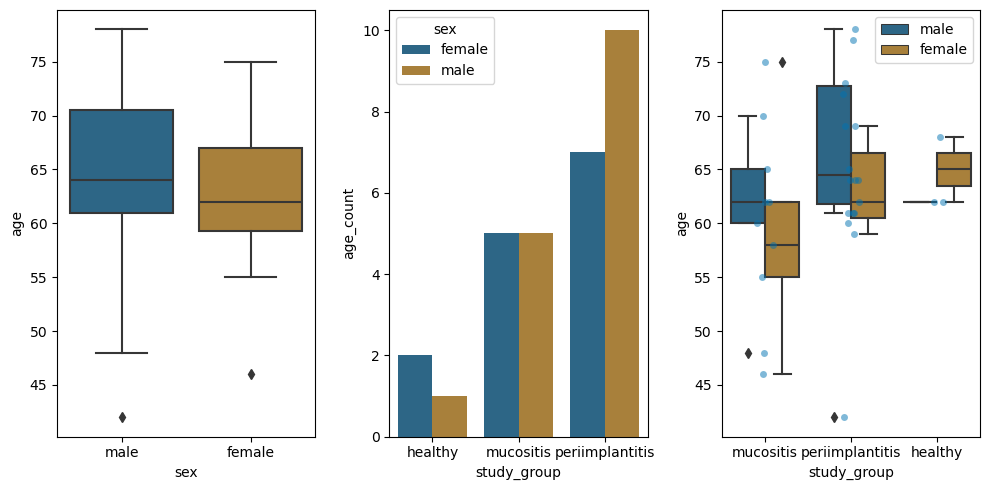

In [8]:
study_group_df = metadata.groupby(["study_group","sex"])["age"].count().to_frame(name="age_count")
study_group_df.reset_index(inplace=True)

fig,ax = plt.subplots(1,3,figsize=(10,5))
sns.boxplot(metadata,x='sex',y='age',saturation=0.5,ax=ax[0])
sns.barplot(data=study_group_df,x="study_group",y="age_count",hue="sex",saturation=0.5,ax=ax[1])
sns.boxplot(data=metadata, x="study_group",y="age",hue="sex",saturation=0.5,ax=ax[2])
sns.stripplot(data=metadata,x="study_group",y="age",alpha=0.5,ax=ax[2])

plt.tight_layout()

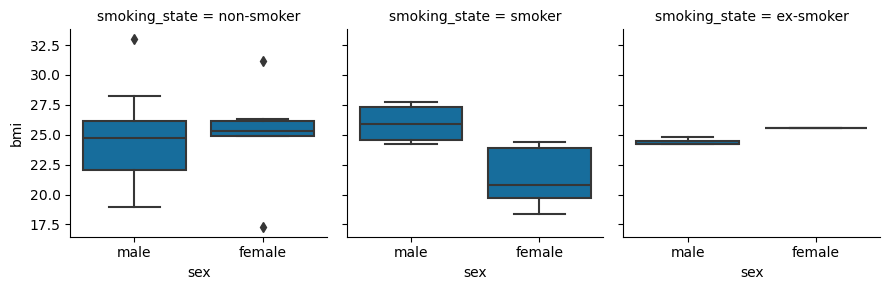

In [9]:
sns.FacetGrid(metadata,col="smoking_state").map_dataframe(sns.boxplot,x="sex",y="bmi")

# Checkm quality analysis

In [ ]:
env = os.environ.copy()
env["MPLBACKEND"] = "Agg"
checkm_result = subprocess.run([
    'bash',
    '-c',
    f""" cd {project_dir}
        CONDA_BASE=$(conda info --base)
        source $CONDA_BASE/etc/profile.d/conda.sh
        mkdir -p checkm_output
        if [ ! -d "extracted_mags" ] || [ -z "$(ls -A "extracted_mags")" ]; then
            mkdir -p extracted_mags
            for bz2_file in mags/*.bz2
            do 
                filename=$( basename "$bz2_file" .bz2 )
                bunzip2 -c "$bz2_file" > extracted_mags/"$filename"
            done
        fi

        conda activate checkm
        checkm taxonomy_wf domain Bacteria extracted_mags checkm_output -t 4
    """
],env=env)

In [10]:
def get_col_names(df):
    colnames = []
    for key,_ in df.iloc[0].str.split(pat=':'):
        colnames.append(key.strip("{").strip(" '").strip("'").replace(" ","_").lower())
    return colnames

def get_value(x):
    x=x.split(':')
    return x[1].strip("'").strip(" '")

def quality_classifier(row):
    if row["completeness"] >= 50 and row["completeness"] < 90 and row["contamination"] < 5:
        return 'Medium' 
    elif row["completeness"] >= 90 and row["contamination"] < 5:
        return 'High'
    else :
        return 'Low'
def checkm_stats(path):
    checkmQC_table = pd.read_csv(path,sep='\t',header=None)
    features_complete = checkmQC_table[1].str.split(pat=',',expand=True)
    # predicted_genes = features_complete.iloc[:,27:]
    features = features_complete.iloc[:,:27]
    neat_features= features.applymap(get_value)
    neat_features.columns = get_col_names(features)
    neat_stats = pd.concat([checkmQC_table[0],neat_features],axis=1)
    neat_stats.rename(columns={0:'bin_ID'},inplace=True)
    neat_stats.sort_values(by=['completeness'],inplace=True)
    toconvert = neat_stats.iloc[:,2:].columns
    neat_stats[toconvert] = neat_stats[toconvert].apply(pd.to_numeric)
    neat_stats.sort_values(by=['completeness','contamination'],inplace=True,ascending=[False,True])
    neat_stats['bin_quality'] = neat_stats.apply(quality_classifier,axis=1)
    return neat_stats

neat_features = checkm_stats(project_dir+"/checkm_output/storage/bin_stats_ext.tsv")

neat_features.head()

,bin_ID,marker_lineage,#_genomes,#_markers,#_marker_sets,0,1,2,3,4,...,longest_scaffold,longest_contig,n50_(scaffolds),n50_(contigs),mean_scaffold_length,mean_contig_length,coding_density,translation_table,#_predicted_genes,bin_quality
27,M1846526184,Bacteria,5449,104,58,0,104,0,0,0,...,253640,253640,98516,98516,46439.903846,46439.903846,0.882965,11,2079,High
18,M1702705864,Bacteria,5449,104,58,0,104,0,0,0,...,322473,322473,92645,92645,65076.236842,65076.236842,0.885269,11,2163,High
15,M1650726873,Bacteria,5449,104,58,0,104,0,0,0,...,381878,381878,103516,103516,73731.757576,73731.757576,0.886399,11,2152,High
13,M1548705285,Bacteria,5449,104,58,0,104,0,0,0,...,371733,371733,110801,110801,66763.111111,66763.111111,0.884498,11,2070,High
11,M1419890899,Bacteria,5449,104,58,0,104,0,0,0,...,231316,231316,91855,91855,47103.470588,47103.470588,0.882509,11,2086,High


In [326]:
neat_features.groupby('bin_quality')['bin_quality'].count()

bin_quality
High      15
Medium    15
Name: bin_quality, dtype: int64

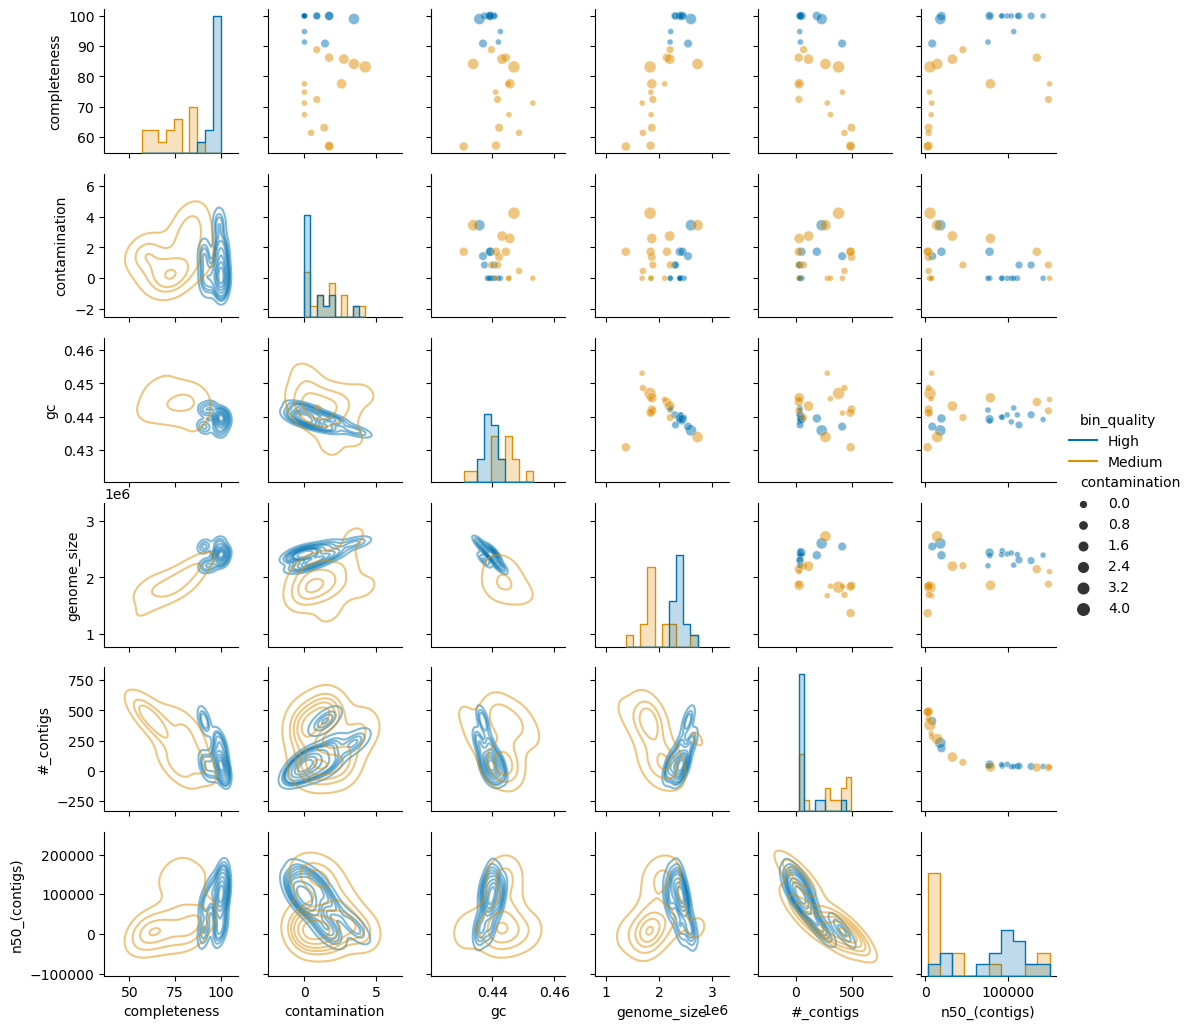

In [481]:
g=sns.PairGrid(neat_features.loc[:,['completeness', 'contamination', 'gc','genome_size','#_contigs', 'n50_(contigs)','bin_quality']],hue='bin_quality',palette='colorblind',height=1.75)
g.map_upper(sns.scatterplot,size=neat_features['contamination'],alpha=0.5)
g.map_diag(sns.histplot,element='step',bins=10)
g.map_lower(sns.kdeplot,alpha=0.5)
g.add_legend(title='',adjust_subtitles=True)

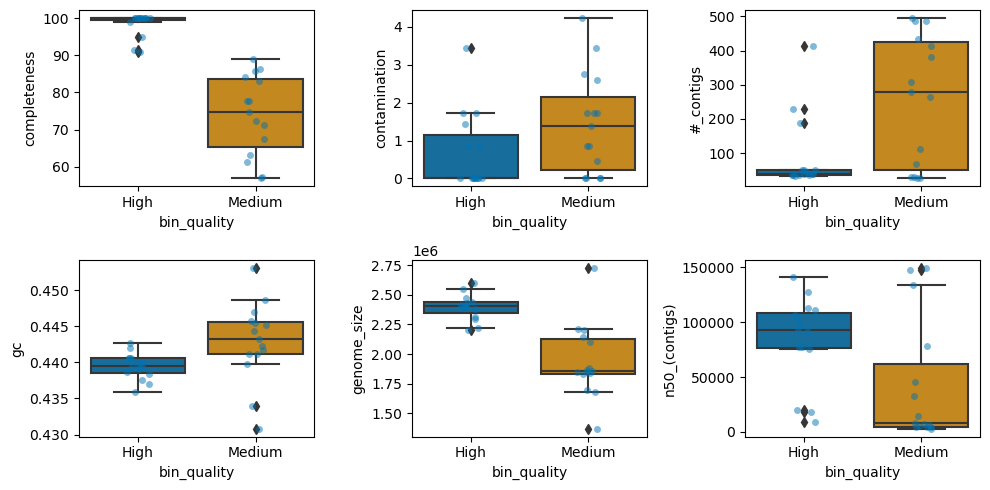

In [360]:
fig,ax=plt.subplots(2,3,figsize=(10,5))
cols = ['completeness','contamination','#_contigs', 'gc', 'genome_size', 'n50_(contigs)']
for i,name in enumerate(cols):
    sns.boxplot(neat_features,y=name,ax=ax[i//3,i%3],x='bin_quality')
    sns.stripplot(neat_features,x="bin_quality",y=name,alpha=0.5,ax=ax[i//3,i%3])
plt.tight_layout()

<Axes: xlabel='genome_size', ylabel='#_predicted_genes'>

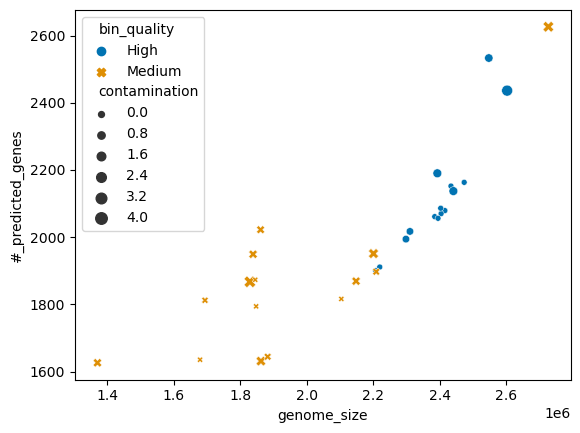

In [ ]:
sns.scatterplot(neat_features,x='genome_size',y='#_predicted_genes',style='bin_quality',hue='bin_quality',size='contamination') ## invert size


# PhyloPhlAn taxonomic assignments

In [ ]:
# phylophlan_result = subprocess.run([
#     'bash','-c',
#     f"""CONDA_BASE=$(conda info --base)
#         source $CONDA_BASE/etc/profile.d/conda.sh
#         conda activate ppa
#         cd {project_dir}
#         ls
#         if [ ! -d "ppa_output" ] || [ -z "$(ls -A ppa_output)" ]; then
#             mkdir -p ppa_output
#         fi
#         phylophlan_metagenomic -i mags -o ppa_output/ppa_m --nproc 4 -n 1 -d "CMG2526" --database_folder ppa_db --verbose

# """
# ],check=False,capture_output=True,text=True)
# print(phylophlan_result.stderr)


[e] expected str, bytes or os.PathLike object, not NoneType

[e] error while sketching
    mags/M1831926750.fna.bz2
    ppa_output/ppa_m_sketches/inputs/M1831926750.fna
    True

[e] expected str, bytes or os.PathLike object, not NoneType

[e] sketching crashed



In [211]:
def get_ppa_df(path):
    df = pd.read_csv(path+"/ppa_output/ppa_m.tsv",sep='\t')
    features_df = df.iloc[:,1].str.split(':',expand=True)
    taxonomic_class_df = features_df.iloc[:,2].str.split('|',expand=True)
    clean_df = pd.DataFrame({
        "bin_ID" : df.loc[:,"#input_bin"],
        "kingdom" : taxonomic_class_df.iloc[:,0],
        "phylum" : taxonomic_class_df.iloc[:,1],
        "class" : taxonomic_class_df.iloc[:,2],
        "order":taxonomic_class_df.iloc[:,3],
        "family":taxonomic_class_df.iloc[:,4],
        "genus":taxonomic_class_df.iloc[:,5],
        "species":taxonomic_class_df.iloc[:,6],
        "SGB":features_df.iloc[:,0],
        "distance":features_df.iloc[:,3]
    })
    clean_df=clean_df.apply(lambda r:r.str.replace(r'^.*__','',regex=True),axis=1)
    return clean_df

In [212]:
ppa_df = get_ppa_df(project_dir)
ppa_df.head()

,bin_ID,kingdom,phylum,class,order,family,genus,species,SGB,distance
0,M1247523836,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella_koreensis,kSGB_1580,0.029867163636363638
1,M1025245651,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella_koreensis,kSGB_1580,0.02779790743801653
2,M1314714359,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella_koreensis,kSGB_1580,0.023137478512396694
3,M1320943765,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella_koreensis,kSGB_1580,0.024146907438016528
4,M1213021579,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella_koreensis,kSGB_1580,0.031661422314049587


In [215]:

print(f"Are all the MAGS from the same SGB? {True if len(ppa_df['SGB'].unique())==1 else False}\nSGB taxon : {ppa_df['SGB'].unique()}\nUnique species : {ppa_df['species'].unique()}")

Are all the MAGS from the same SGB? True
SGB taxon : ['kSGB_1580']
Unique species : ['Prevotella_koreensis']


# Prokka annotations

In [ ]:
prokka_result = subprocess.run([
    'bash',
    '-c',
    f"""CONDA_BASE=$(conda info --base)
        source $CONDA_BASE/etc/profile.d/conda.sh
        conda activate prokka
        cd {project_dir}
        ls
        if [ ! -d "extracted_mags" ] || [ ! -z "$(ls -A extracted_mags)" ]; then
            mkdir -p extracted_mags
            for bz2_file in mags/* .bz2
            do 
                filename=$( basename "$bz2_file" .bz2 )
                bunzip2 -c "$bz2_file" > extracted_mags/"$filename"
            done
        fi
        mkdir -p prokka_output
        # if [ -d "prokka_output" ] && [ ! -z "$(ls -A prokka_output)" ];then
        #     echo "clearing folder for re-analysis"
        #     rm -f prokka_output/*
        # fi

        for file in extracted_mags/*
        do
            echo "Running $file ..."
            mag=$( basename "$file" .fna )
            mkdir -p prokka_output/$mag
            prokka extracted_mags/"$mag".fna \
                --quiet \
		        --outdir prokka_output/"$mag" \
                --compliant \
		        --force \
		        --prefix "$mag" 2>&1 | tee prokka_output/$mag/prokka.log
        done
        conda deactivate

    """
],stdout=None,stderr=None)

In [11]:
def make_dataframe(path,ID):
    df = pd.read_csv(path,sep='\t')
    df = df.loc[df['ftype']=='CDS']
    df.insert(0,"bin_ID",ID)
    return df

def prokka_stats(path):
    df_list=[]
    for sub_dir in os.listdir(path+"/prokka_output"):
        ID = sub_dir
        for file in os.listdir(path+"/prokka_output/"+sub_dir):
            if file.endswith('.tsv'):
                df_list.append(make_dataframe(path+"/prokka_output/"+sub_dir+'/'+file,ID))

            else:
                continue
    stats_df = pd.concat(df_list,ignore_index=True)
    return stats_df
CDS_stats=prokka_stats(project_dir)

In [12]:
CDS_stats

,bin_ID,locus_tag,ftype,length_bp,gene,EC_number,COG,product
0,M1709480479,AAEJFGAO_00001,CDS,552,NaN,NaN,NaN,hypothetical protein
1,M1709480479,AAEJFGAO_00002,CDS,579,NaN,NaN,NaN,hypothetical protein
2,M1709480479,AAEJFGAO_00003,CDS,951,rgtE,2.4.1.-,COG0463,Dodecaprenyl-phosphate galacturonate synthase
3,M1709480479,AAEJFGAO_00004,CDS,486,NaN,NaN,NaN,hypothetical protein
4,M1709480479,AAEJFGAO_00005,CDS,684,NaN,NaN,NaN,hypothetical protein
...,...,...,...,...,...,...,...,...
55839,M1846526184,OFFJBEEN_02091,CDS,111,NaN,NaN,NaN,hypothetical protein
55840,M1846526184,OFFJBEEN_02092,CDS,1671,NaN,NaN,NaN,hypothetical protein
55841,M1846526184,OFFJBEEN_02093,CDS,1332,NaN,NaN,NaN,IS1380 family transposase ISDau1
55842,M1846526184,OFFJBEEN_02094,CDS,1026,NaN,NaN,NaN,hypothetical protein


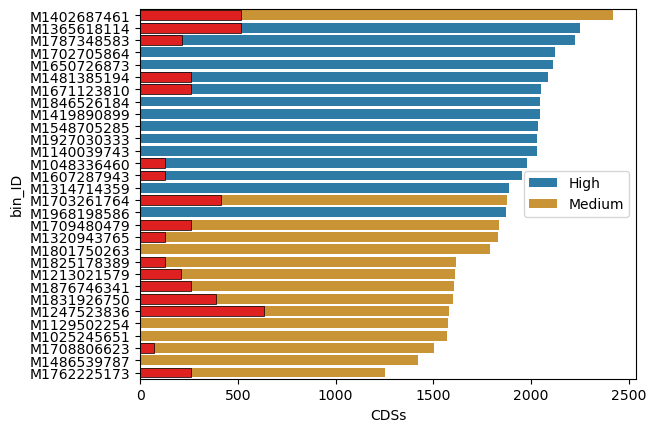

In [540]:
cds_count = CDS_stats.groupby('bin_ID')['ftype'].count().to_frame(name='CDSs').reset_index()
cds_count=cds_count.merge(neat_features[['bin_ID','bin_quality','contamination']],on='bin_ID',how='left').sort_values('CDSs',ascending=False).reset_index(drop=True)
cds_count['contamination'] = cds_count['contamination']*150
fig,ax = plt.subplots()
sns.barplot(cds_count,y='bin_ID',x='CDSs',hue='bin_quality',hue_order=['High','Medium'],orient='h',dodge=False,alpha=.9)
sns.barplot(cds_count,y='bin_ID',x='contamination',orient='h',color='red',edgecolor='black',linewidth=.5)
ax.set_xlabel('CDSs')
ax.legend()



In [601]:
cds_count

,bin_ID,CDSs,bin_quality,contamination
0,M1402687461,2418,Medium,3.448276
1,M1365618114,2250,High,3.448276
2,M1787348583,2228,High,1.436782
3,M1702705864,2125,High,0.000000
4,M1650726873,2112,High,0.000000
5,M1481385194,2088,High,1.724138
6,M1671123810,2052,High,1.724138
7,M1846526184,2047,High,0.000000
8,M1419890899,2047,High,0.000000
9,M1548705285,2036,High,0.000000


In [14]:
product_df=CDS_stats.loc[CDS_stats['product']=='hypothetical protein'].groupby(['bin_ID'])['product'].count().sort_values(ascending=False).to_frame(name='hyp_protein')
product_df['known_protein']=CDS_stats.loc[CDS_stats['product']!='hypothetical protein'].groupby('bin_ID')['product'].count()

In [16]:
product_df.sum()

hyp_protein      31758
known_protein    24086
dtype: int64

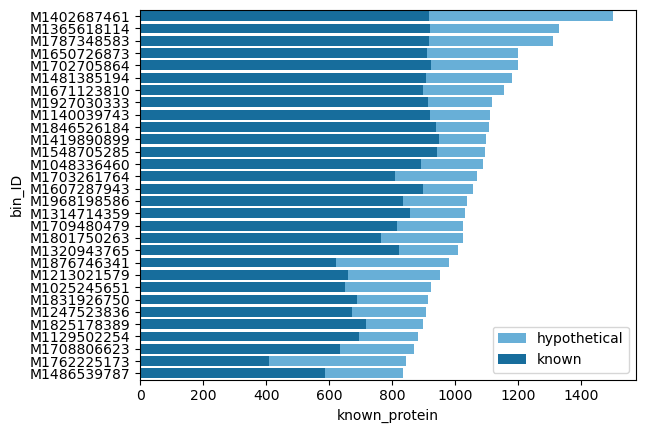

In [517]:
fig,ax = plt.subplots()
sns.barplot(product_df,y=product_df.index,x='hyp_protein',color=sns.color_palette('colorblind')[9],orient='h',label='hypothetical')
sns.barplot(product_df,y=product_df.index,x='known_protein',color=sns.color_palette('colorblind')[0],orient='h',label='known')

ax.legend()

# Roary visualizations

In [ ]:
roary = subprocess.run(['bash','-c',
                        f"""
                        CONDA_BASE=$(conda info --base)
                        source $CONDA_BASE/etc/profile.d/conda.sh
                        conda activate roary
                        cd {project_dir}
                        
                        roary prokka_output/*/*.gff -i 95 -cd 90 -f roary_output -p 8

                        conda deactivate
"""
],stdout=None,stderr=None)

In [620]:
def get_roary_matrix(path,annotations=False):
    df= pd.read_csv(path+"/gene_presence_absence.csv")
    df.set_index('Gene',inplace=True)
    if annotations is True:
        return df['Annotation']
    else:
        matrix = df.iloc[:,13:]
        matrix.replace(np.nan,0,inplace=True)
        matrix.replace({'.'},1,regex=True,inplace=True)
        return matrix

def get_top_genes(matrix,path,notcore=False):
    annotation_matrix = matrix.copy()
    annotation_matrix.insert(0,'Annotation',get_roary_matrix(path,True))
    annotation_matrix.reset_index(inplace=True)
    if notcore is False:
        top = annotation_matrix.set_index('Annotation').sum(axis=1,numeric_only=True).groupby('Annotation').sum().sort_values(ascending=False).to_frame(name='count')
        return top
    else:
        not_core=annotation_matrix.loc[annotation_matrix.sum(axis=1,numeric_only=True)<=15]
        not_core = not_core.set_index('Annotation').sum(axis=1,numeric_only=True).groupby('Annotation').sum().sort_values(ascending=False).to_frame(name='count')
        return not_core.iloc[1:]


roary_matrix = get_roary_matrix(path=project_dir+"/roary_output")
top_genes = get_top_genes(roary_matrix,path=project_dir+"/roary_output")

<Axes: ylabel='Annotation'>

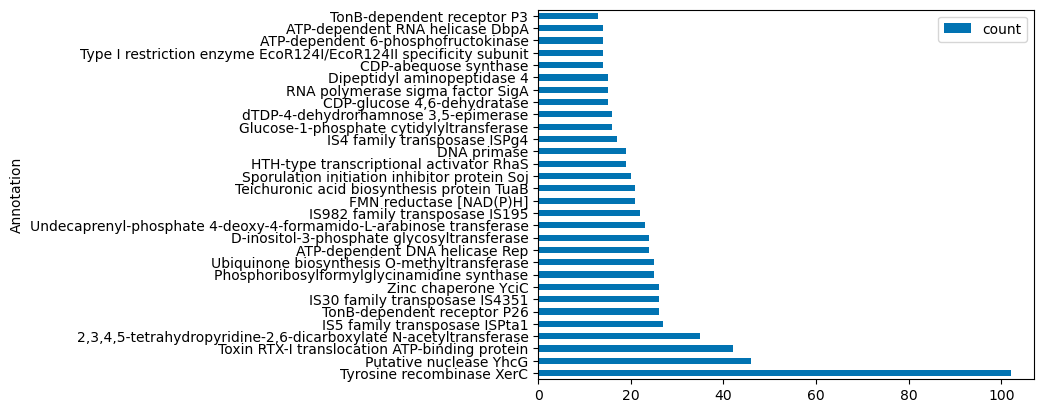

In [626]:
top_not_core = get_top_genes(roary_matrix,
                             path=project_dir+"/roary_output",notcore=True)
top_not_core[:30].plot.barh()

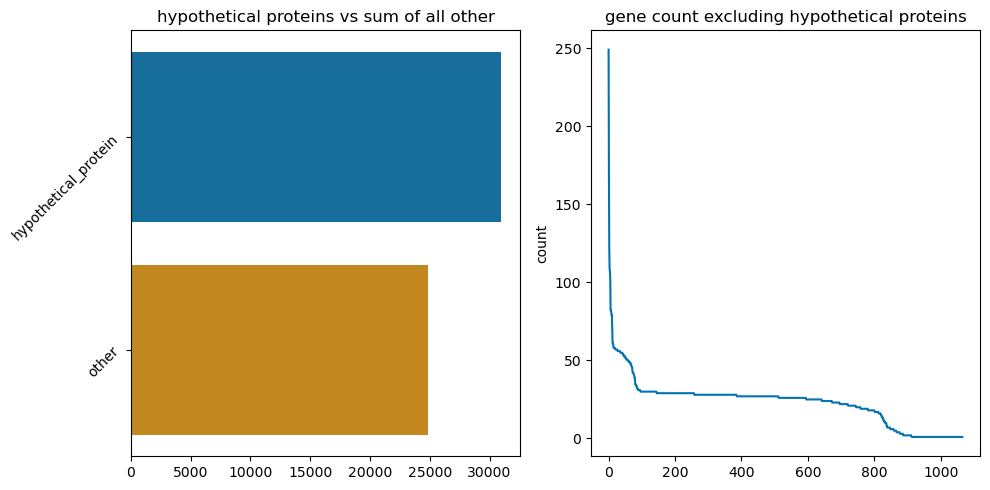

In [627]:

top_genes_excl_hyp=top_genes.iloc[1:]
countlist = [top_genes.iloc[:1,0],top_genes_excl_hyp.sum()]
fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.barplot(countlist,ax=ax[0],orient='h')
sns.lineplot(top_genes_excl_hyp,x=list(range(top_genes_excl_hyp.shape[0])),y='count',ax=ax[1])
ax[0].set_title("hypothetical proteins vs sum of all other")
ax[0].set_yticklabels(['hypothetical_protein', 'other'],rotation=45)
ax[1].set_title("gene count excluding hypothetical proteins")
ax[1].set_ylabel("count")
plt.tight_layout()

Text(0.5, 1.0, 'Top 30 genes -EXCLUDING hypothetical proteins-')

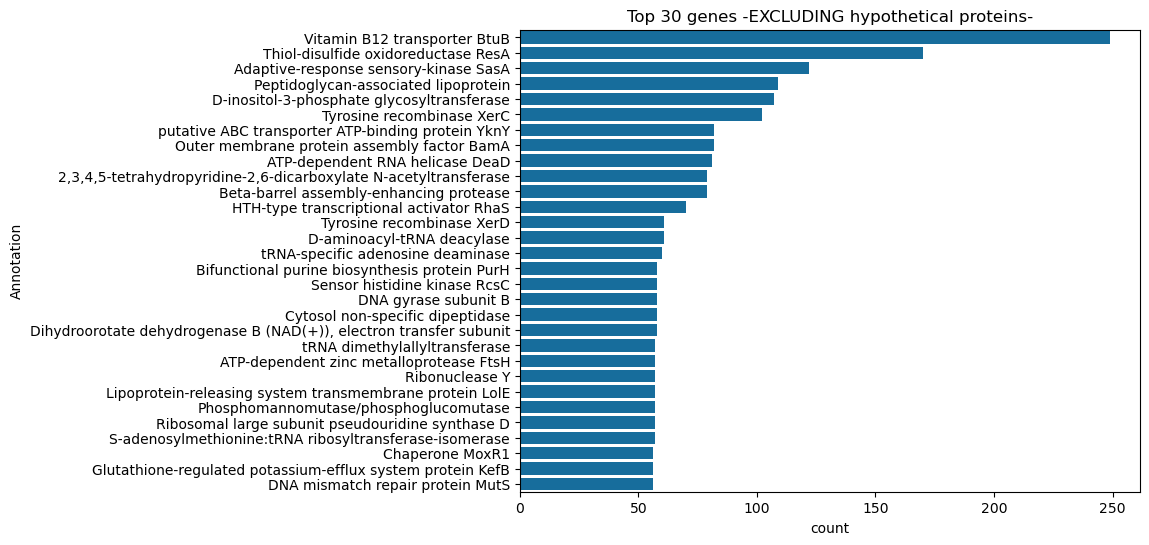

In [628]:

fig,ax=plt.subplots(figsize=(8,6))
sns.barplot(top_genes_excl_hyp.iloc[:30],y=top_genes_excl_hyp.iloc[:30].index,x='count',orient='h',color=sns.color_palette('colorblind')[0],ax=ax)
ax.set_title("Top 30 genes -EXCLUDING hypothetical proteins-")

In [613]:
colormap = metadata[['magID','study_group','smoking_state']].sort_values(by='study_group').set_index('magID')
colormap['study_group']= colormap['study_group'].map( {"healthy": "#4BD34F","mucositis": "#FF9800","periimplantitis": "#E53535"})
colormap['smoking_state'] = colormap['smoking_state'].map({"smoker":"#AC36CA","non-smoker":"#FAD52F","ex-smoker":"#6CB6E0"})

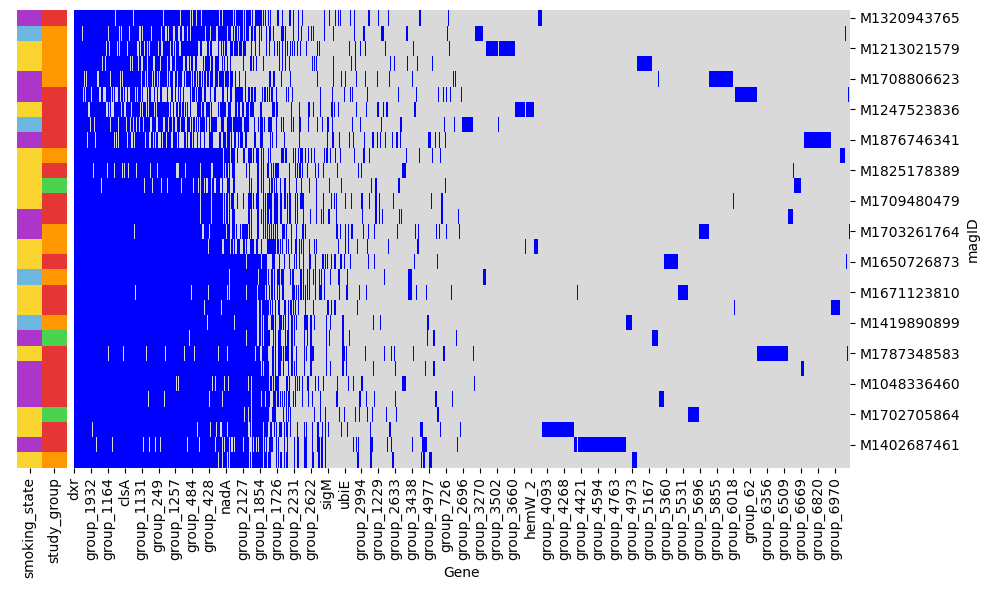

In [629]:
filtered_matrix=roary_matrix.loc[(roary_matrix.sum(axis=1)<=30) &  (roary_matrix.sum(axis=1)>=0)]
filtered_matrix=filtered_matrix.T.reindex(metadata[['magID','study_group']].sort_values(by='study_group')['magID']).dropna(how='all')
colormap=colormap.loc[filtered_matrix.index]

roary_tree = Phylo.read(project_dir+"/roary_output/accessory_binary_genes.fa.newick","newick")
tip_order = [t.name for t in roary_tree.get_terminals()]
tree_filtered_matrix = filtered_matrix.loc[[x for x in tip_order if x in filtered_matrix.index]]
rdgn = sns.color_palette(['.85','Blue'],n_colors=2)

sns.clustermap(tree_filtered_matrix,
               cmap=rdgn,
               row_cluster=False,
               row_colors=colormap[['smoking_state','study_group']],
               col_cluster=False,
               cbar_pos=None,
               dendrogram_ratio=(0,0),
               figsize=(10,6))

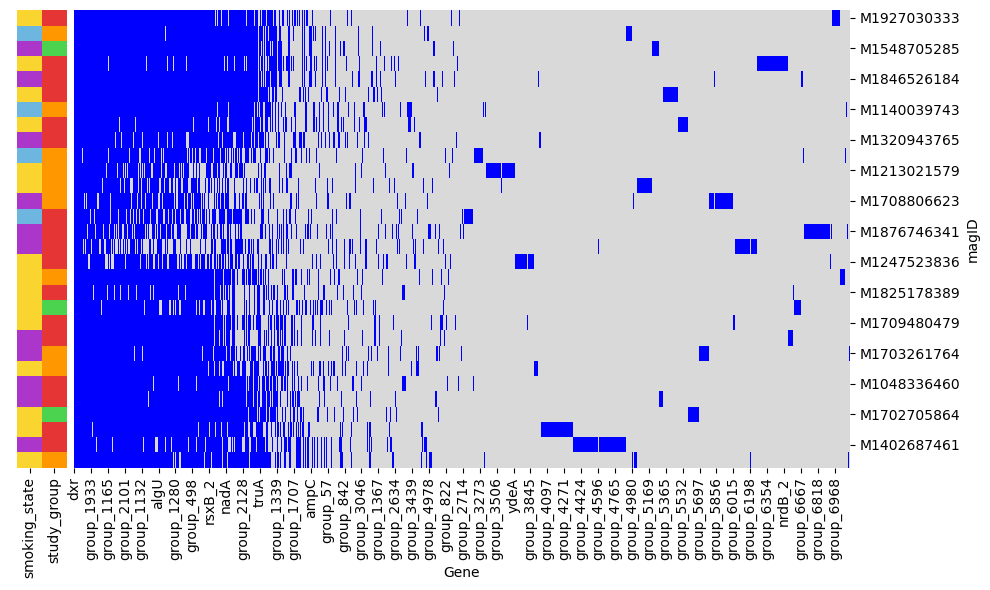

In [630]:
filtered_matrix=get_roary_matrix(project_dir+"/roary_output_w_aln")
filtered_matrix=filtered_matrix.T.reindex(metadata[['magID','study_group']].sort_values(by='study_group')['magID']).dropna(how='all')
colormap=colormap.loc[filtered_matrix.index]

roary_tree = Phylo.read(project_dir+"/roary_output_w_aln/accessory_binary_genes.fa.newick","newick")
tip_order = [t.name for t in roary_tree.get_terminals()]
tree_filtered_matrix = filtered_matrix.loc[[x for x in tip_order if x in filtered_matrix.index]]
rdgn = sns.color_palette(['.85','Blue'],n_colors=2)

sns.clustermap(tree_filtered_matrix,
               cmap=rdgn,
               row_cluster=False,
               row_colors=colormap[['smoking_state','study_group']],
               col_cluster=False,
               cbar_pos=None,
               dendrogram_ratio=(0,0),
               figsize=(10,6))

AttributeError: 'DataFrame' object has no attribute 'unique'

<Axes: ylabel='Count'>

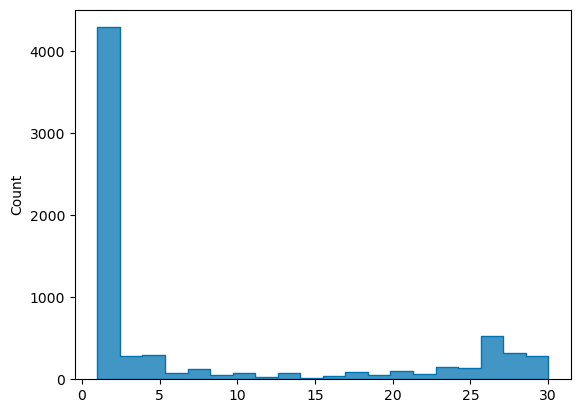

In [583]:
roary_sorted=roary_matrix.sum(axis=1).sort_values(ascending=False)
sns.histplot(roary_sorted,element='step',color=sns.color_palette('colorblind')[0])

In [58]:
newgenes_Rtab_csv = pd.read_csv(project_dir+"/roary_output/number_of_new_genes.Rtab",sep='\t',header=None)
conservedgenes_Rtab_csv = pd.read_csv(project_dir+"/roary_output/number_of_conserved_genes.Rtab",sep='\t',header=None)
uniquegenes_Rtab_csv = pd.read_csv(project_dir+"/roary_output/number_of_unique_genes.Rtab",sep='\t',header=None)
pangenomegenes_Rtab_csv = pd.read_csv(project_dir+"/roary_output/number_of_genes_in_pan_genome.Rtab",sep='\t',header=None)

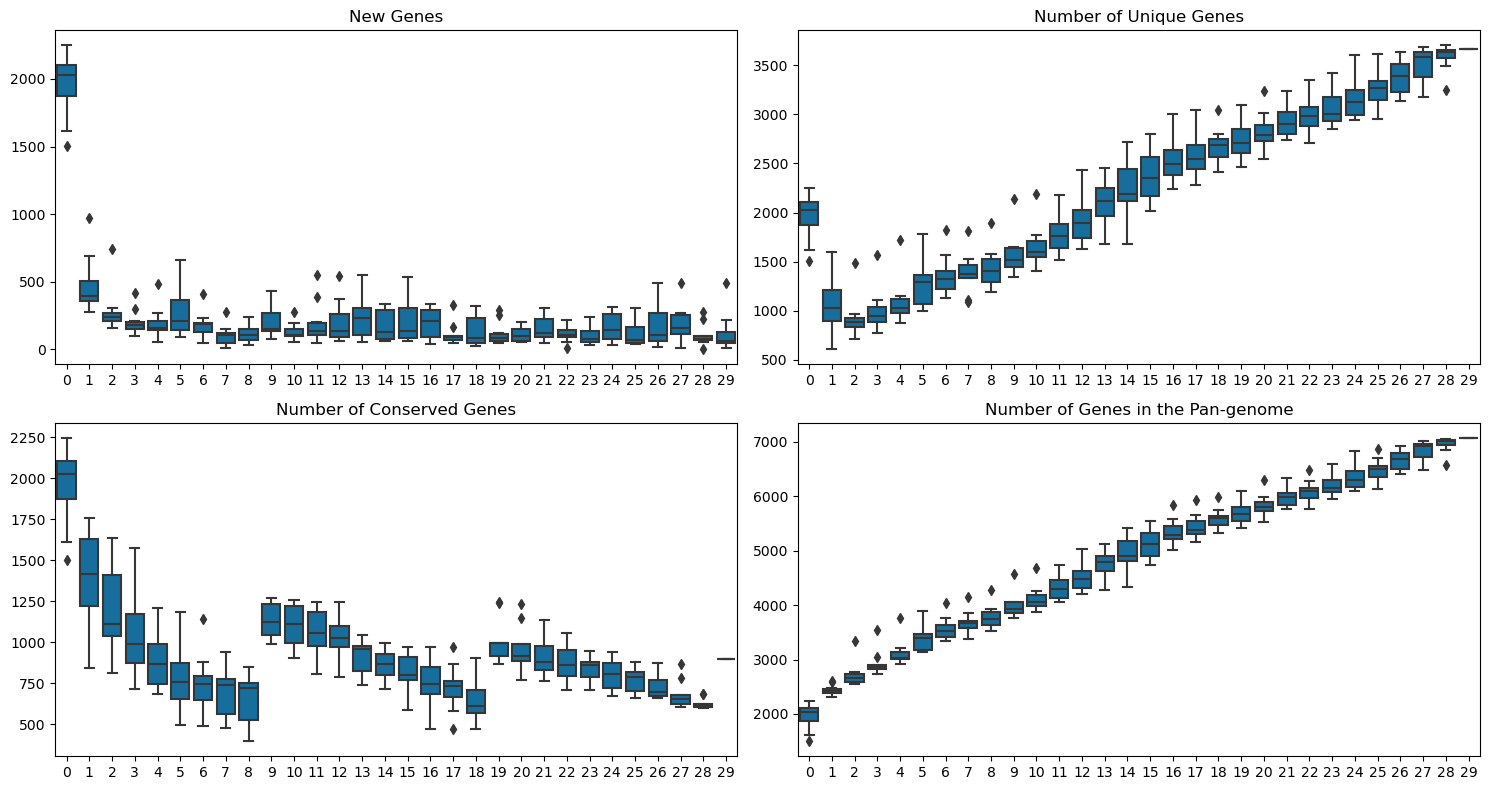

In [59]:

df_list = [newgenes_Rtab_csv,uniquegenes_Rtab_csv,conservedgenes_Rtab_csv,pangenomegenes_Rtab_csv]
titles = ["New Genes","Number of Unique Genes","Number of Conserved Genes","Number of Genes in the Pan-genome"]
fig,ax=plt.subplots(2,2,figsize=(15,8))
for i,(df,t) in enumerate(zip(df_list,titles)) :
    sns.boxplot(df,color=sns.color_palette('colorblind')[0],ax=ax[i//2,i%2])
    ax[i//2,i%2].set_title(t)
plt.tight_layout()

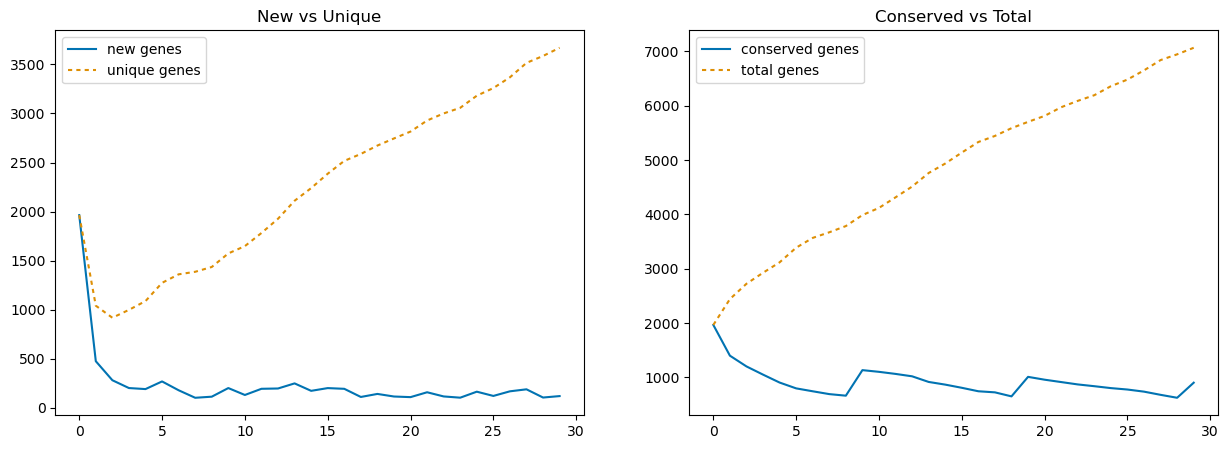

In [103]:

labels=["new genes","unique genes","conserved genes","total genes"]
fig,ax = plt.subplots(1,2,figsize=(15,5))
for i,(df,t) in enumerate(zip(df_list,labels)):
    sns.lineplot(df.mean(),ax=ax[i//2],label=t, dashes= (2,2) if i%2 == 1 else "")
    ax[i//2].set_title("New vs Unique" if i//2 == 0 else "Conserved vs Total")
    ax[i//2].legend()

## Pan-genome open/closed estimation using Heap's Law
### we can use Heap's law's alpha to estimate if the pan-genome is open or closed 
### $n = kN^{-\alpha}$

### if $\alpha$ is < 1 then the pan-genome can be considered open 
### if  $\alpha$ is > 1 the pan-genome is closed


In [124]:
from scipy.stats import linregress
y = newgenes_Rtab_csv.mean().values
x = newgenes_Rtab_csv.mean().index +1
fit = linregress(np.log(x),np.log(y))
alpha = -fit.slope

print(f"the \u03B1 coefficient is: {alpha: .2f}")

the α coefficient is:  0.53
